## Import libraries





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Sales data

In [2]:
#First, upload the data into the colab environment
#Then, load the file as a pandas dataframe (df)

df = pd.read_csv('A1_Data_Churn.csv')
df.head()

,age,job,marital status,education,VIP customer,call minutes last year,phone included,os,marketing calls,connection strength,devices,location,churn
0,33,admin,married,tertiary,no,882,no,Android,1,151,3,city,no
1,33,services,married,secondary,no,3444,yes,Android,1,91,4,city,yes
2,36,management,married,tertiary,no,0,yes,Android,1,143,3,city,yes
3,56,technician,married,secondary,no,589,yes,Android,1,147,2,rural,yes
4,51,admin,single,secondary,no,3132,no,Android,1,176,1,city,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6133 entries, 0 to 6132
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age                     6133 non-null   int64 
 1   job                     6133 non-null   object
 2   marital status          6133 non-null   object
 3   education               6133 non-null   object
 4   VIP customer            6133 non-null   object
 5   call minutes last year  6133 non-null   int64 
 6   phone included          6133 non-null   object
 7   os                      6133 non-null   object
 8   marketing calls         6133 non-null   int64 
 9   connection strength     6133 non-null   int64 
 10  devices                 6133 non-null   int64 
 11  location                6133 non-null   object
 12  churn                   6133 non-null   object
dtypes: int64(5), object(8)
memory usage: 623.0+ KB


In [4]:
df.describe(include='all')


,age,job,marital status,education,VIP customer,call minutes last year,phone included,os,marketing calls,connection strength,devices,location,churn
count,6133.000000,6133,6133,6133,6133,6133.000000,6133,6133,6133.000000,6133.000000,6133.000000,6133,6133
unique,NaN,11,3,3,2,NaN,2,2,NaN,NaN,NaN,2,2
top,NaN,management,married,secondary,no,NaN,yes,Android,NaN,NaN,NaN,city,no
freq,NaN,1385,3591,3252,6093,NaN,3818,5293,NaN,NaN,NaN,4709,4629
mean,41.115767,NaN,NaN,NaN,NaN,1601.639654,NaN,NaN,1.940486,223.483939,2.949128,NaN,NaN
std,11.332373,NaN,NaN,NaN,NaN,2964.978193,NaN,NaN,1.428400,113.212305,3.037924,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,217.000000,NaN,NaN,1.000000,131.000000,1.000000,NaN,NaN
50%,38.000000,NaN,NaN,NaN,NaN,620.000000,NaN,NaN,1.000000,190.000000,2.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1791.000000,NaN,NaN,2.000000,325.000000,4.000000,NaN,NaN


In [5]:
df.columns


Index(['age', 'job', 'marital status', 'education', 'VIP customer',
       'call minutes last year', 'phone included', 'os', 'marketing calls',
       'connection strength', 'devices', 'location', 'churn'],
      dtype='object')

In [6]:
df.shape

(6133, 13)

## Data visualization with matplotlib

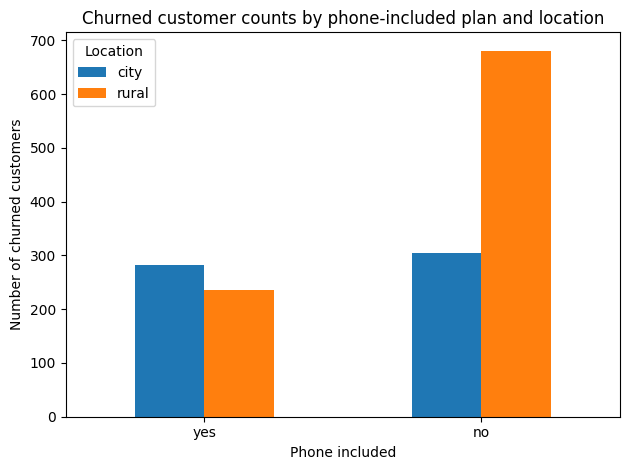

In [8]:

# Filter churned customers only
churn_yes = df[df['churn'].str.lower() == 'yes']

# Count churned customers by Phone Included × Location
counts = (
    churn_yes
    .groupby(['phone included', 'location'])
    .size()
    .unstack(fill_value=0)          # columns: City / Rural
    .reindex(['yes', 'no'])         # order x-axis
)

# Plot grouped bars
ax = counts.plot(kind='bar', rot=0)
ax.set_xlabel('Phone included')
ax.set_ylabel('Number of churned customers')
ax.set_title('Churned customer counts by phone-included plan and location')
ax.legend(title='Location')

plt.tight_layout()
plt.savefig("scatterplot.png", dpi=300)
plt.show()


## Preprocessing


In [12]:
from sklearn.model_selection import train_test_split
#first split the data into train and test
X = df.drop(columns=['churn'])
y = df['churn']
print("values y takes:",y.unique())
#map y to a binary variable (important for postprocessing)
y = y.map({'no': 0, 'yes': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(y_train)

values y takes: ['no' 'yes']
4169    0
120     1
1777    1
6107    1
2694    0
       ..
3772    1
5191    1
5226    1
5390    0
860     0
Name: churn, Length: 4293, dtype: int64


In [13]:
#check for missing values
print("missing values")
print(X_train.isnull().sum())
print(y_train.isnull().sum())

missing values
age                       0
job                       0
marital status            0
education                 0
VIP customer              0
call minutes last year    0
phone included            0
os                        0
marketing calls           0
connection strength       0
devices                   0
location                  0
dtype: int64
0


In [22]:
#dummy encoding:
from sklearn.preprocessing import OneHotEncoder
#get the categorical features in a list
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
categorical_cols_list = categorical_cols.tolist()
print("categories:",categorical_cols_list)

#if you want to drop the first column of the one-hot encoding:
encoder = OneHotEncoder(handle_unknown="error", drop='first', sparse_output=False)

#The encoder is first fit on the training data
encoder.fit(X_train[categorical_cols])
#then it is used to transform the features of the training and test data
X_train_dummy = encoder.transform(X_train[categorical_cols])
X_test_dummy = encoder.transform(X_test[categorical_cols])
#transform into dataframe again (don't forget the index!)
X_train_dummy = pd.DataFrame(X_train_dummy, columns=encoder.get_feature_names_out(categorical_cols_list),index=X_train.index)
X_test_dummy = pd.DataFrame(X_test_dummy, columns=encoder.get_feature_names_out(categorical_cols_list),index=X_test.index)
#
X_train_dummy_encoded= pd.concat([X_train.drop(columns=categorical_cols_list), X_train_dummy], axis=1)
X_test_dummy_encoded = pd.concat([X_test.drop(columns=categorical_cols_list), X_test_dummy], axis=1)

# X_train_encoded.head()
print(X_train_dummy_encoded.shape)
X_train.shape

categories: ['job', 'marital status', 'education', 'VIP customer', 'phone included', 'os', 'location']
(4906, 23)


(4906, 12)

## Training a decision tree

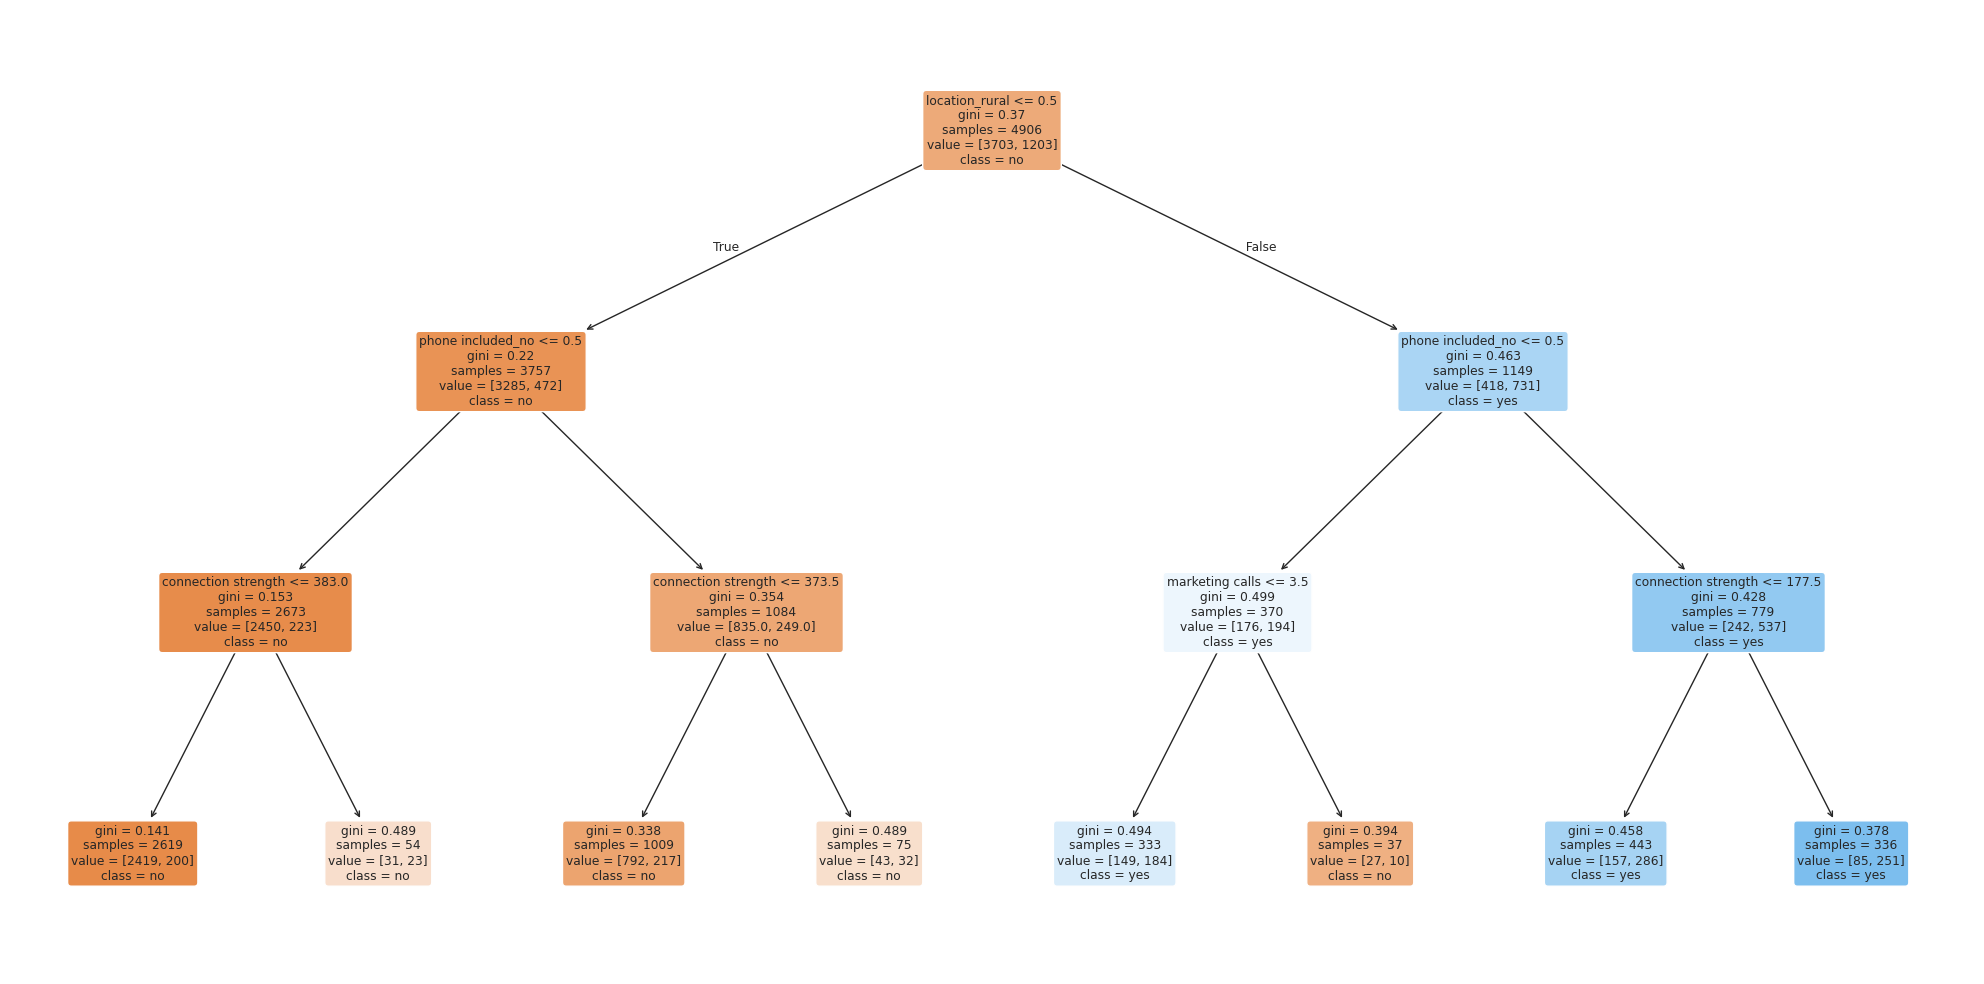

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Target (0/1)
y = df['churn'].str.lower().map({'no': 0, 'yes': 1})

# Features
X = df.drop(columns=['churn'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Columns by type
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Preprocess + model
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

clf = Pipeline(steps=[
    ('prep', preprocess),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=3))
])

# Fit
clf.fit(X_train, y_train)
# Get feature names after one-hot encoding
ohe = clf.named_steps['prep'].named_transformers_['cat']
ohe_names = ohe.get_feature_names_out(cat_cols)
feature_names = list(ohe_names) + list(num_cols)

plt.figure(figsize=(20, 10))
plot_tree(
    clf.named_steps['model'],
    feature_names=feature_names,
    filled=True, rounded=True,
    class_names=['no','yes']
)
plt.tight_layout()
plt.show()


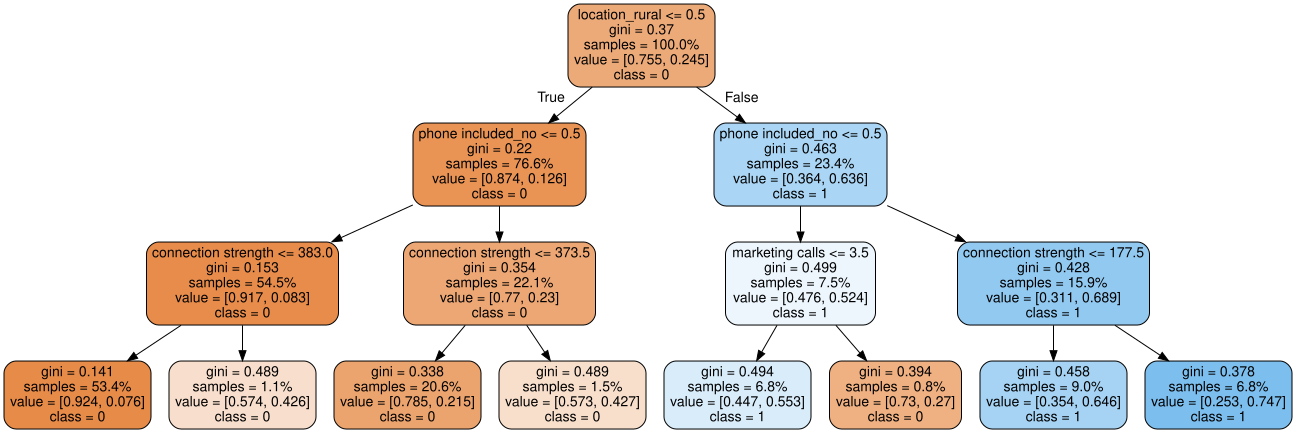

In [16]:
#For a cleaner visualization:
from sklearn.tree import export_graphviz
from graphviz import Source

# Extract the fitted DecisionTreeClassifier
tree_model = clf.named_steps['model']

dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=feature_names,    # use the one we created before
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    proportion=True
)


Source(dot_data)
graph = Source(dot_data)
graph.render("tree_visualization", format="png", cleanup=True)
Source(dot_data)


Train Accuracy: 0.822
Test Accuracy:  0.837
Train ROC-AUC:  0.812
Test ROC-AUC:   0.828


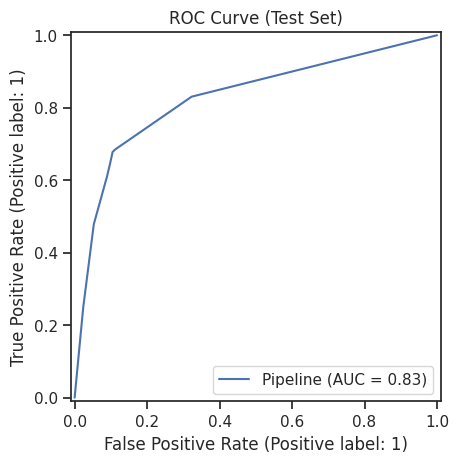

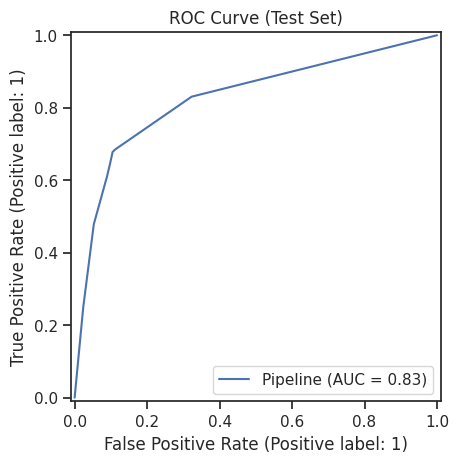

In [17]:
from sklearn.metrics import roc_auc_score, accuracy_score

# 1️⃣ Make predictions on train and test
y_pred_train = clf.predict(X_train)
y_pred_test  = clf.predict(X_test)

# For ROC-AUC, you need probabilities (not class labels)
y_prob_train = clf.predict_proba(X_train)[:, 1]
y_prob_test  = clf.predict_proba(X_test)[:, 1]

# 2️⃣ Compute metrics
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)

roc_train = roc_auc_score(y_train, y_prob_train)
roc_test  = roc_auc_score(y_test, y_prob_test)

# 3️⃣ Print results
print(f"Train Accuracy: {acc_train:.3f}")
print(f"Test Accuracy:  {acc_test:.3f}")
print(f"Train ROC-AUC:  {roc_train:.3f}")
print(f"Test ROC-AUC:   {roc_test:.3f}")

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.title("ROC Curve (Test Set)")
plt.show()
from sklearn.metrics import RocCurveDisplay
disp = RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.title("ROC Curve (Test Set)")
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")  # save first
plt.show()



# Evaluation

[[0.92363498 0.07636502]
 [0.92363498 0.07636502]
 [0.35440181 0.64559819]
 ...
 [0.25297619 0.74702381]
 [0.92363498 0.07636502]
 [0.78493558 0.21506442]]


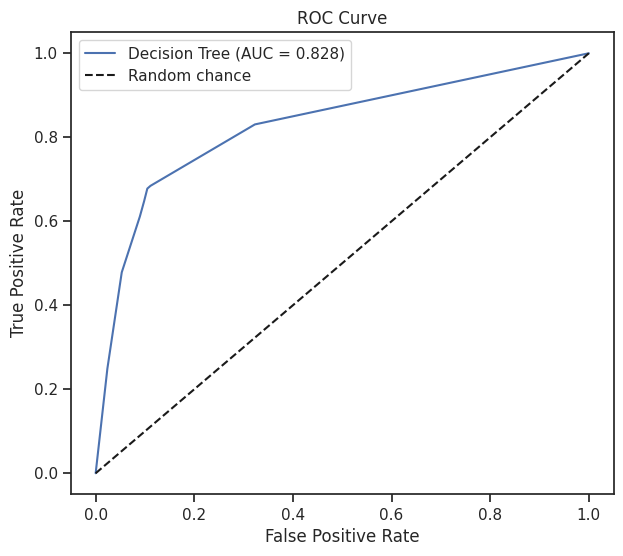

In [20]:
from sklearn.metrics import roc_curve,roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
#For evaluation, predictions are made on the TEST set
#Never only show performance on the training set because you might have overfitted
# Get predicted probabilities for the positive class
print(clf.predict_proba(X_test))
#This outputs an array of size (n_test, 2), where the first column gives the predicted probability
#of Sale_Y = 0, and the second column the probability of Sale_Y = 1
y_proba = clf.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)


# Plot ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [24]:
#Other metrics:
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.837000814995925
Precision: 0.6891385767790262
Recall: 0.6112956810631229
F1 Score: 0.647887323943662


In [25]:
#define a reusable function to get all metrics for different thresholds
def get_metrics(my_clf,threshold,X):
    y_proba = my_clf.predict_proba(X)[:, 1]
    y_pred_threshold = (y_proba >= threshold).astype(int)
    print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall:", recall_score(y_test, y_pred_threshold))
    print("F1 Score:", f1_score(y_test, y_pred_threshold))

In [26]:
#ROC calculation already gives relevant thresholds:
print(thresholds)

[       inf 0.74702381 0.64559819 0.55255255 0.42666667 0.42592593
 0.27027027 0.21506442 0.07636502]


In [28]:
#Increase recall --> see how there is a tradeoff between accuracy, precision, recall and F1!
threshold = 0.2 #change this to see what happens to metrics
get_metrics(clf,threshold,X_test)


Accuracy: 0.7147514262428688
Precision: 0.4553734061930783
Recall: 0.8305647840531561
F1 Score: 0.5882352941176471


## Using cross-validation

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, roc_auc_score, f1_score, recall_score, precision_score, accuracy_score

# Initialize the model
clf = DecisionTreeClassifier(random_state=42, max_depth=3)

# Define multiple scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}
#because we use the full dataset we can use the train and test set both
X = pd.concat([X_train_dummy_encoded, X_test_dummy_encoded])
y = pd.concat([y_train, y_test])


# Perform 5-fold cross-validation
cv_results = cross_validate(clf, X, y, cv=5, scoring=scoring)

# Print results --> note that if a threshold is needed, 0.5 is used
for metric in scoring.keys():
    print(f"{metric.capitalize()} per fold: {cv_results[f'test_{metric}']}")
    print(f"Mean {metric}: {cv_results[f'test_{metric}'].mean():.3f}")
    print(f"Std {metric}: {cv_results[f'test_{metric}'].std():.3f}")
    print()

Accuracy per fold: [0.80358598 0.83211084 0.82396088 0.80587276 0.83686786]
Mean accuracy: 0.820
Std accuracy: 0.014

Precision per fold: [0.60067114 0.68339768 0.64026403 0.60689655 0.68913858]
Mean precision: 0.644
Std precision: 0.037

Recall per fold: [0.59468439 0.58803987 0.64451827 0.58666667 0.61129568]
Mean recall: 0.605
Std recall: 0.022

F1 per fold: [0.59766277 0.63214286 0.64238411 0.59661017 0.64788732]
Mean f1: 0.623
Std f1: 0.022

Roc_auc per fold: [0.78429892 0.81044108 0.8253446  0.79773758 0.82769687]
Mean roc_auc: 0.809
Std roc_auc: 0.016



## Alternative: WOE encoding


This installs the package to google colab

In [31]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 10.1 MB/s eta 0:00:00


In [34]:
from feature_engine.encoding import WoEEncoder
import pandas as pd

# Dynamically identify categorical columns from X_train
# This ensures the list is always correct for the current DataFrame
all_categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Identify columns that caused the WoEEncoder error (education, and potentially 'job' if it has pure categories)
# Based on previous analysis and correcting for the non-existent 'occupation' column.
dummy_cols = ['education', 'job']

# Identify columns that can be safely WoE encoded
woe_cols = [col for col in all_categorical_cols if col not in dummy_cols]

print(f"Columns for WoE encoding: {woe_cols}")
print(f"Columns for Dummy encoding: {dummy_cols}")

# Initialize WoEEncoder for the non-problematic categorical columns
woe_encoder = WoEEncoder(variables=woe_cols)

# Fit the WoEEncoder on the training data (only for the specified WoE columns)
# It calculates WoE values based on X_train and y_train for the 'woe_cols'
woe_encoder.fit(X_train, y_train)

# Transform X_train and X_test using the fitted WoEEncoder.
# This will replace the 'woe_cols' with their WoE values and leave other columns (numerical, dummy_cols) unchanged.
X_train_processed = woe_encoder.transform(X_train)
X_test_processed = woe_encoder.transform(X_test)

# Apply dummy encoding to the problematic columns for both train and test sets.
# These columns are still present in X_train_processed and X_test_processed in their original string form.
X_train_woe = pd.get_dummies(X_train_processed, columns=dummy_cols, drop_first=True)
X_test_woe = pd.get_dummies(X_test_processed, columns=dummy_cols, drop_first=True)

print("\nWoE encoding applied to:", woe_cols)
print("Dummy encoding applied to:", dummy_cols)
print("\nShape of X_train_woe (fixed):", X_train_woe.shape)
print("Shape of X_test_woe (fixed):", X_test_woe.shape)

Columns for WoE encoding: ['marital status', 'VIP customer', 'phone included', 'os', 'location']
Columns for Dummy encoding: ['education', 'job']

WoE encoding applied to: ['marital status', 'VIP customer', 'phone included', 'os', 'location']
Dummy encoding applied to: ['education', 'job']

Shape of X_train_woe (fixed): (4906, 22)
Shape of X_test_woe (fixed): (1227, 22)


The above code gives an error because some categories are only 1, or only 0. To resolve this we will dummy encode those columns, and use woe encoding for the others

In [ ]:
from feature_engine.encoding import WoEEncoder
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
categorical_cols_list = categorical_cols.tolist()
#remove workclass,education, marital_status, occupation, and native country
categorical_cols_list.remove('education')
categorical_cols_list.remove('occupation')
dummy_list = ['education','occupation']
#create the encoder
woe_encoder = WoEEncoder(variables=categorical_cols_list)
#here we actually "fit" the encoder on the training data
# ---> NEVER fit an encoder on the test data because this is data leakage
woe_encoder.fit(X_train, y_train)
X_train_woe = woe_encoder.transform(X_train)
X_test_woe = woe_encoder.transform(X_test)

X_train_woe = pd.get_dummies(X_train_woe, columns=dummy_list, drop_first=True)
X_test_woe = pd.get_dummies(X_test_woe, columns=dummy_list, drop_first=True)

X_train_woe.columns

Index(['age', 'workclass', 'networth', 'duration_relationship',
       'marital_status', 'living_with', 'region', 'pet', 'donations_2021',
       'donations_2022', 'voluntary_work_per_quarter', 'native_country',
       'education_11th', 'education_12th', 'education_1st-4th',
       'education_5th-6th', 'education_7th-8th', 'education_9th',
       'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors',
       'education_Doctorate', 'education_HS-grad', 'education_Masters',
       'education_Prof-school', 'education_Some-college',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specialty',
       'occupation_Protective-serv', 'occupation_Sales',
       'occupation_Tech-support', 'occupation_Transport-moving'],
      dtype='object')

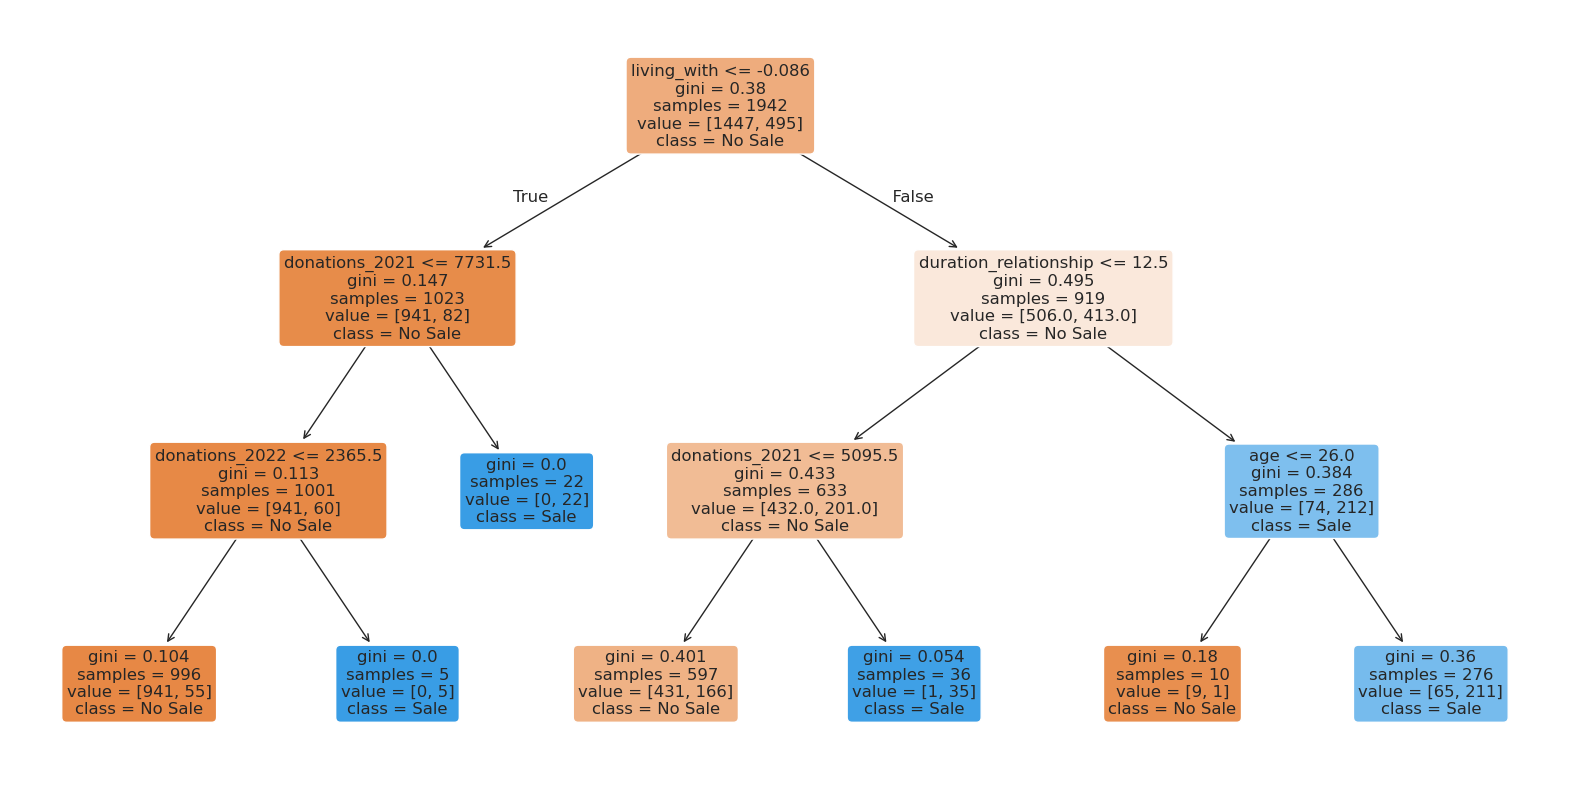

In [ ]:
#Train decision tree
clf_woe = DecisionTreeClassifier(random_state=42,max_depth=3)
clf_woe.fit(X_train_woe, y_train)

plt.figure(figsize=(20,10))
plot_tree(clf_woe, feature_names=X_train_woe.columns.tolist(), filled=True, rounded=True, class_names=['No Sale', 'Sale'])
plt.savefig('decision_tree_woe.png', dpi=300) #This png is save in files
plt.show()

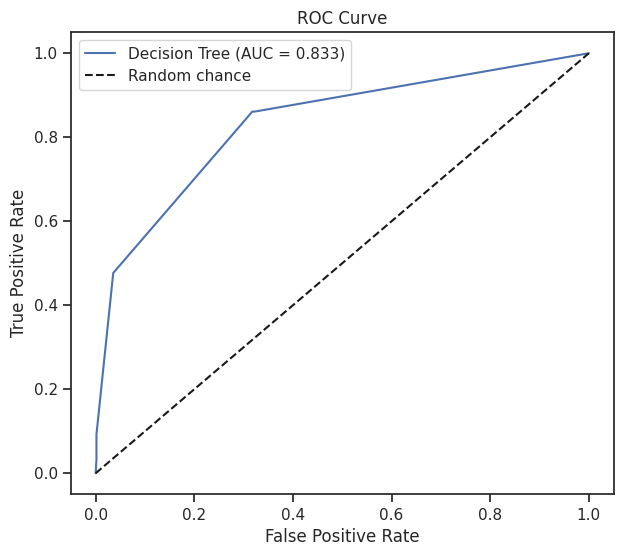

In [ ]:
#get roc curve
y_proba = clf_woe.predict_proba(X_test_woe)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

#plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()